In [5]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 656.2 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.1 MB 656.2 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/8.1 MB 650.3 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.1 MB 698.5 kB/s eta 0:00:11
   ----- ---------------------------------- 1.0/8.1 MB 698.5 kB/s eta 0:00:11
   ----- ---------------------------------- 1.0/8.1 MB 698.5 kB/s eta 0:00:11
   ------ --------------------------------- 1.3/8.1 MB 639.0 kB/s eta 0:00:11
   ------ --------------------------------- 1.3/8.1 MB 639.0 kB/s eta 0:00:11
   ------- -------------------------------- 1.6/8.1 MB 609.2 kB/s eta 0:00:11
   ------- -----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load the cleaned data
df = pd.read_csv("cleaned_ebay_deals.csv")
df.head()

,timestamp,title,price,original_price,shipping,item_url,discount_percentage
0,2026-03-10 14:59:51.139287,"Sony Xperia 10 IV 5G XQ-CC54 128GB 6.0"" Androi...",171.58,171.58,Free shipping,https://www.ebay.com/itm/197837525392?_trkparm...,0.0
1,2026-03-10 14:59:51.374812,Nokia 1209 - Midnight Blue (Unlocked) Cellular...,36.97,NaN,Free shipping,https://www.ebay.com/itm/167612398310?_trkparm...,NaN
2,2026-03-10 14:59:51.623120,Cartine Rizla Liquorice Corte – Gusto Naturale...,35.94,35.94,Free shipping,https://www.ebay.com/itm/364382641988?_trkparm...,0.0
3,2026-03-10 14:59:51.850503,Honor Magic V 5G 512GB Google Android 12 Snapd...,540.76,540.76,Free shipping,https://www.ebay.com/itm/406378990824?_trkparm...,0.0
4,2026-03-10 14:59:51.995007,NaN,NaN,NaN,NaN,https://www.ebay.com/globaldeals/tech/cell-pho...,NaN


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


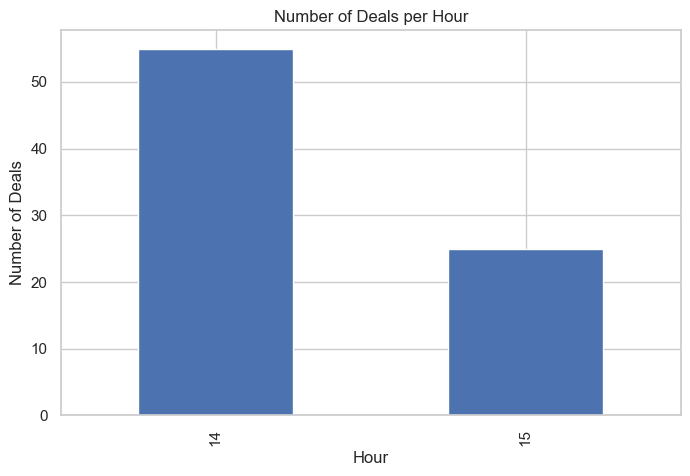

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df["hour"] = df["timestamp"].dt.hour

deals_per_hour = df.groupby("hour").size()

plt.figure(figsize=(8,5))
deals_per_hour.plot(kind="bar")
plt.title("Number of Deals per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Deals")
plt.show()

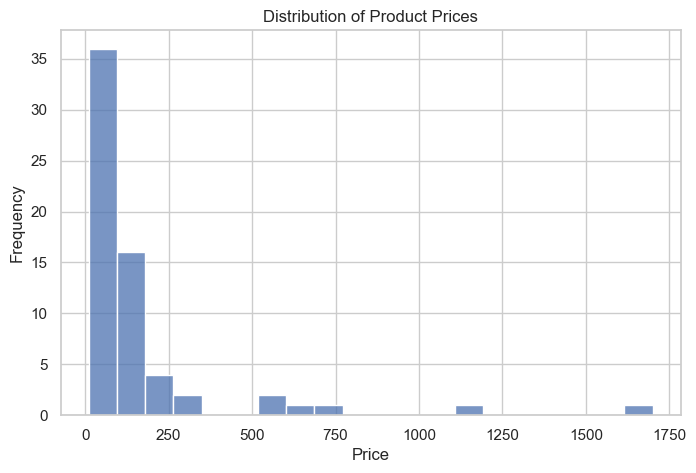

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=20)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

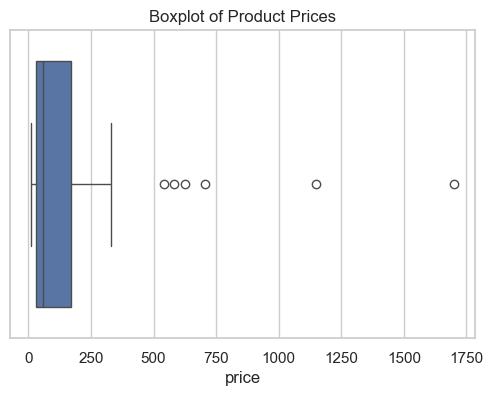

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Product Prices")
plt.show()

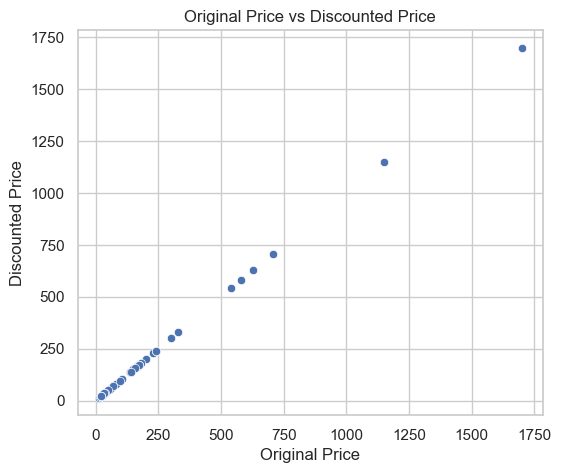

In [12]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["original_price"], y=df["price"])
plt.title("Original Price vs Discounted Price")
plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.show()



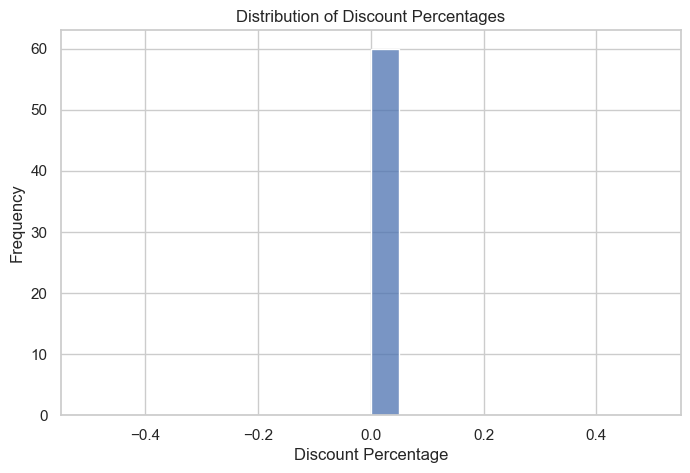

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["discount_percentage"], bins=20)
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.show()

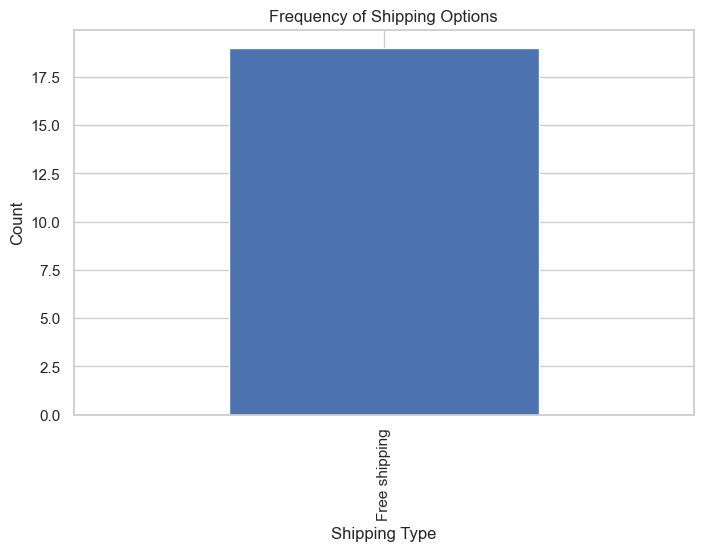

In [14]:
shipping_counts = df["shipping"].value_counts()

plt.figure(figsize=(8,5))
shipping_counts.plot(kind="bar")
plt.title("Frequency of Shipping Options")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.show()

C:\Users\ZERO3.CO\AppData\Local\Temp\ipykernel_24712\4216331889.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_series.index, y=keyword_series.values, palette="viridis")


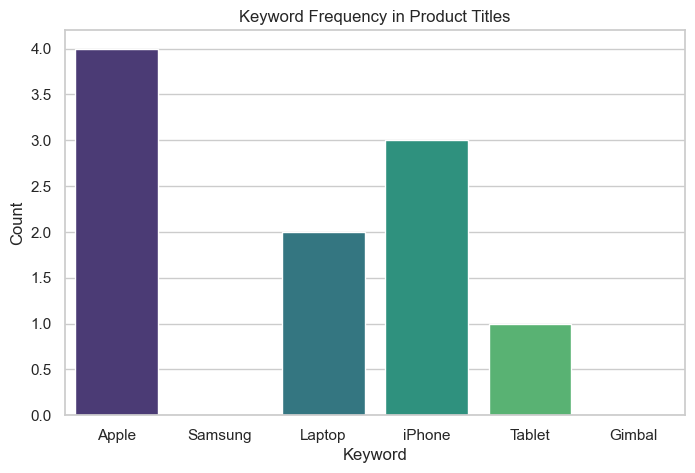

In [15]:
keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal"]

keyword_counts = {}
for word in keywords:
    keyword_counts[word] = df["title"].str.contains(word, case=False).sum()

keyword_series = pd.Series(keyword_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=keyword_series.index, y=keyword_series.values, palette="viridis")
plt.title("Keyword Frequency in Product Titles")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.show()

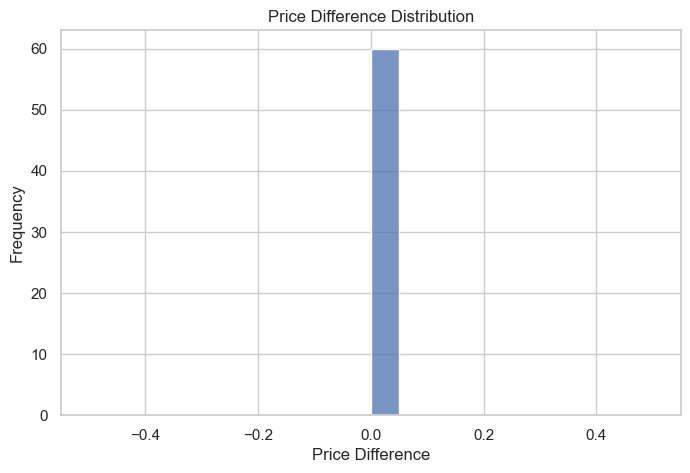

In [16]:
df["price_difference"] = df["original_price"] - df["price"]

plt.figure(figsize=(8,5))
sns.histplot(df["price_difference"], bins=20)
plt.title("Price Difference Distribution")
plt.xlabel("Price Difference")
plt.ylabel("Frequency")
plt.show()

In [17]:
top5 = df.sort_values("discount_percentage", ascending=False).head(5)
top5[["title", "price", "original_price", "discount_percentage"]]

,title,price,original_price,discount_percentage
0,"Sony Xperia 10 IV 5G XQ-CC54 128GB 6.0"" Androi...",171.58,171.58,0.0
2,Cartine Rizla Liquorice Corte – Gusto Naturale...,35.94,35.94,0.0
3,Honor Magic V 5G 512GB Google Android 12 Snapd...,540.76,540.76,0.0
5,Lenvo ThinkPad T540P i7 8GB 240GB SSD 15.6 Zol...,230.70,230.70,0.0
6,HP Elitebook 840 G8 i7-11651G7 2.8GHz 16 GB RA...,299.99,299.99,0.0
